<a href="https://colab.research.google.com/github/rafa-jel/PCVK26_21_Rafazl/blob/main/PCVK_W3_244107020082_Rafazl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Rafazl Radana Diva'
NIM = '244107020082' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Rafazl Radana Diva
NIM : 244107020082 | N = 82
b      : 41
a      : 1.1
c      : 32
gamma  : 1.4
bit    : 6
WAKTU : 2026-09-28 10:55:55 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 542d6eae3d0c7686


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukan nilai kecerahan 250


/tmp/ipykernel_491/3733910138.py:20: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


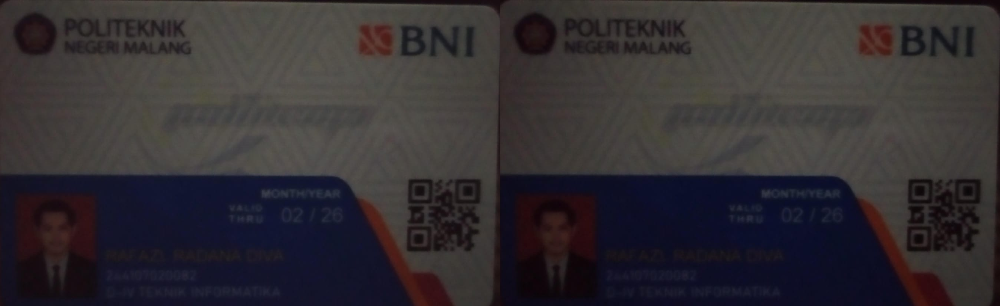

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
  brightness = int(input('Masukan nilai kecerahan '))
except ValueError:
  print('Error, not a number')

#sesuaikan dengan file dan folder di drive anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM1a.jpeg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)


Hasil Inverse Citra: /content/drive/MyDrive/PCVK/Images/KTM1a.jpeg
----------------------------------


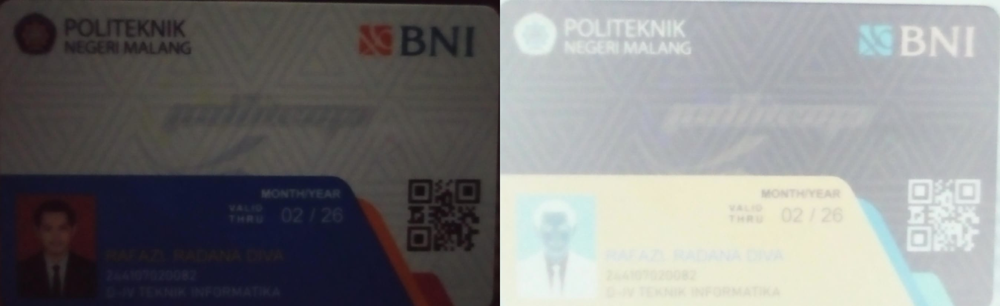


Hasil Inverse Citra: /content/drive/MyDrive/PCVK/Images/KTM1b.jpeg
----------------------------------


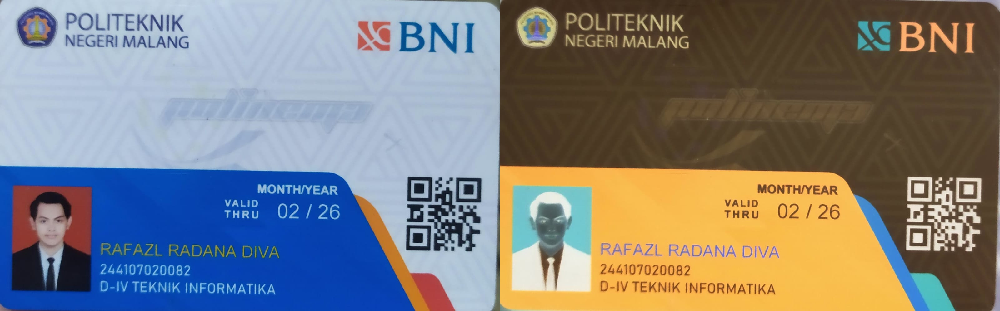

In [ ]:
# TUGAS PRAKTIKUM
# 1.
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

def proses_inverse_citra(path_gambar):
    # Membaca citra asli
    original = cv.imread(path_gambar)

    # Memastikan gambar berhasil dimuat
    if original is None:
        print(f"Error: File tidak ditemukan di {path_gambar}")
        return

    # Menerapkan formula inverse (citra negatif)
    inverse_image = 255 - original

    # Menggabungkan citra asli dan inverse secara horizontal
    final_frame = cv.hconcat((original, inverse_image))

    print(f'\nHasil Inverse Citra: {path_gambar}')
    print('----------------------------------')
    cv2_imshow(final_frame)

# Menjalankan fungsi untuk kedua gambar (sesuaikan path dengan folder Anda)
path_KTM1a = '/content/drive/MyDrive/PCVK/Images/KTM1a.jpeg'
path_KTM1b = '/content/drive/MyDrive/PCVK/Images/KTM1b.jpeg'

proses_inverse_citra(path_KTM1a)
proses_inverse_citra(path_KTM1b)

KTM1a (Ruangan Gelap): Karena diambil di ruangan gelap, citra asli KTM1a didominasi oleh piksel dengan nilai intensitas rendah (mendekati 0). Saat dilakukan operasi inverse ($255 - \text{nilai piksel}$), hampir semua piksel gelap tersebut berubah nilainya menjadi sangat tinggi (mendekati 255 atau putih).

KTM1b (Tetap Kontras): Citra ini kemungkinan besar memiliki rentang dinamis yang lebih baik dengan pencahayaan normal, artinya nilai piksel tersebar secara merata dari gelap hingga terang. Saat diinversi, area terang berubah menjadi gelap dan area gelap berubah menjadi terang, namun jarak variasi antar pikselnya (kontras) tetap terjaga.

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan : 30
Masukkan kontras : 1.5


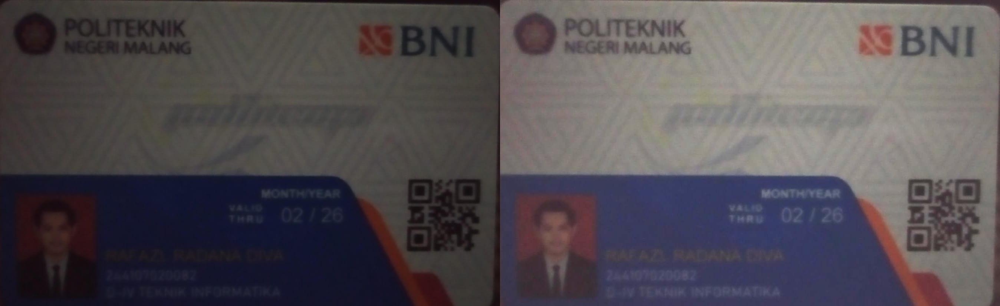

In [ ]:
# 2
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
    # Meminta input sesuai dengan contoh keluaran
    brightness = int(input('Masukkan tingkat kecerahan : '))
    kontras = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, masukkan angka yang valid')

# Sesuaikan path dengan lokasi file KTM1a.jpg di Google Drive Anda
path_gambar = '/content/drive/MyDrive/PCVK/Images/KTM1a.jpeg'
original = cv.imread(path_gambar)

if original is None:
    print(f"Error: Gambar tidak ditemukan di {path_gambar}")
else:
    # Menggunakan np.clip untuk menjaga nilai piksel dalam rentang 0-255.
    # Operasi matematiknya: piksel_baru = (piksel_lama * kontras) + brightness
    transformed_image = np.clip(kontras * original.astype(np.float32) + brightness, 0, 255).astype(np.uint8)

    # Menggabungkan gambar secara horizontal (kiri: asli, kanan: hasil)
    final_frame = cv.hconcat((original, transformed_image))

    # Menampilkan hasil
    cv2_imshow(final_frame)

Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------------------------------
Masukkan nilai kecerahan (c): 50
Masukkan nilai kecerahan linier (b): 40

Hasil Transformasi Logaritma:


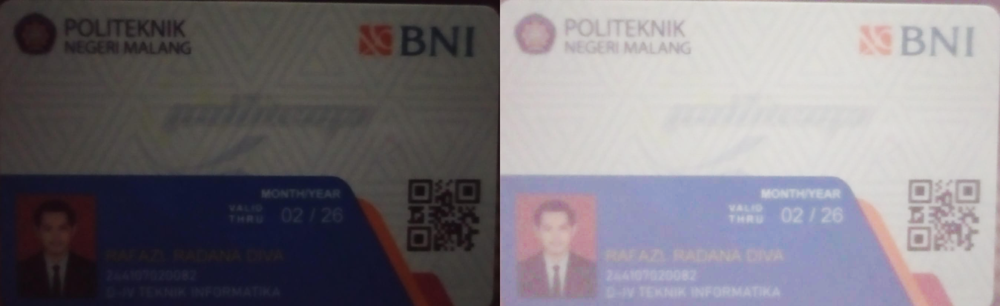


Hasil Transformasi Linier:


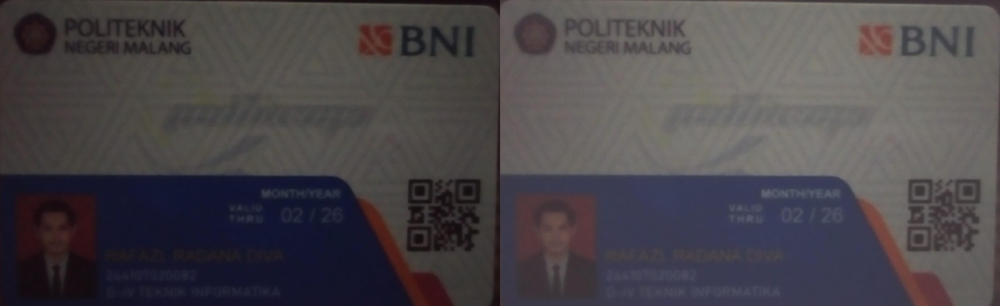


Area Clipping (Ditandai Merah) - Kiri: Logaritma, Kanan: Linier:


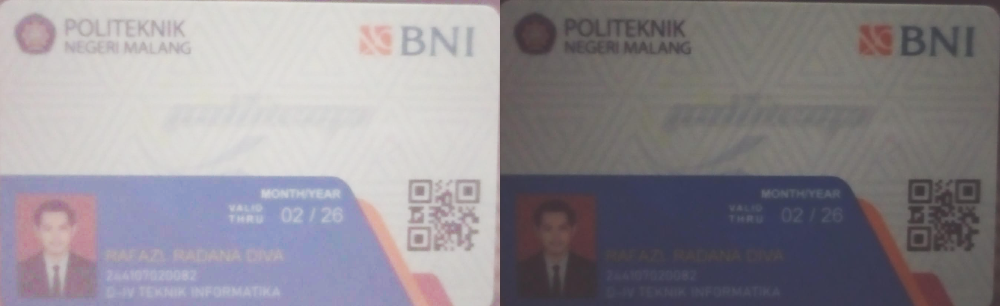

In [ ]:
# 3
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')
try:
    # Meminta input konstanta c (log) dan b (linier) dari perhitungan NIM
    c = float(input('Masukkan nilai kecerahan (c): '))
    b = int(input('Masukkan nilai kecerahan linier (b): '))
except ValueError:
    print('Error, masukkan angka yang valid')

path_gambar = '/content/drive/MyDrive/PCVK/Images/KTM1a.jpeg'
original = cv.imread(path_gambar)

if original is not None:
    # Mengamankan kalkulasi dengan float32
    img_float = original.astype(np.float32)

    # 1. Transformasi Logarithmic: s = c * log(1 + r)
    # np.log1p adalah fungsi Numpy untuk log(1 + x) yang menghindari pembagian nol
    log_image = c * np.log1p(img_float)
    log_image = np.clip(log_image, 0, 255).astype(np.uint8)

    # 2. Transformasi Linier: s = r + b
    linear_image = np.clip(img_float + b, 0, 255).astype(np.uint8)

    # Menampilkan hasil Transformasi Logarithmic (kiri: asli, kanan: log)
    print('\nHasil Transformasi Logaritma:')
    final_frame_log = cv.hconcat((original, log_image))
    cv2_imshow(final_frame_log)

    # Menampilkan perbandingan Linier sebagai tambahan
    print('\nHasil Transformasi Linier:')
    final_frame_linear = cv.hconcat((original, linear_image))
    cv2_imshow(final_frame_linear)

    # 3. Deteksi area Clipping (Piksel yang menjadi putih penuh / 255)
    # Membuat mask merah untuk menyorot area yang mengalami clipping
    clipping_log = np.where(log_image == 255, [0, 0, 255], log_image).astype(np.uint8)
    clipping_linier = np.where(linear_image == 255, [0, 0, 255], linear_image).astype(np.uint8)

    print('\nArea Clipping (Ditandai Merah) - Kiri: Logaritma, Kanan: Linier:')
    final_clipping = cv.hconcat((clipping_log, clipping_linier))
    cv2_imshow(final_clipping)

else:
    print("Error: Gambar tidak ditemukan. Pastikan path direktori benar.")

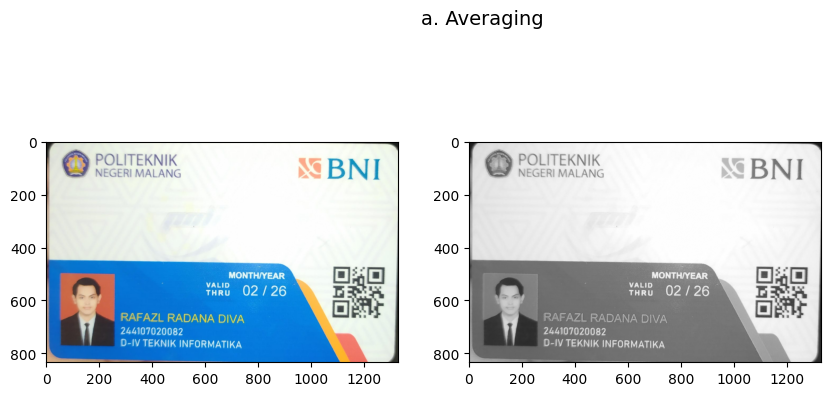

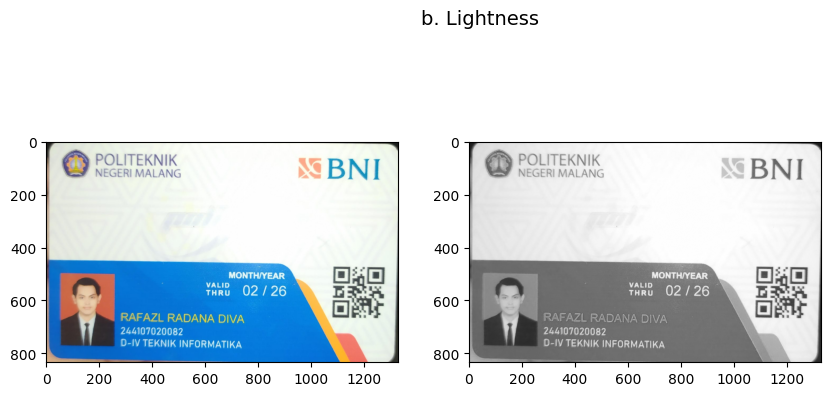

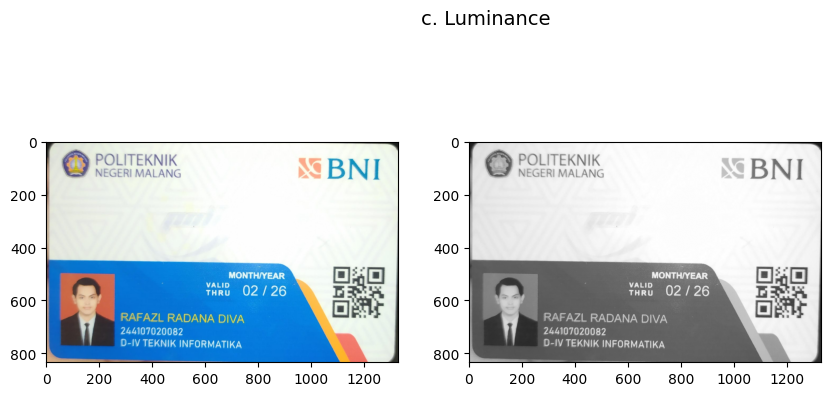


Tabel Nilai Intensitas Citra Grayscale:
--------------------------------------------------
   Metode  Rata-rata (Mean)  Simpangan Baku (Std Dev)
Averaging        192.534916                 63.471853
Lightness        191.950897                 64.342779
Luminance        189.120785                 69.430736


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 4
path_gambar = '/content/drive/MyDrive/PCVK/Images/KTM1c.jpeg'
img_bgr = cv.imread(path_gambar)

if img_bgr is not None:
    # Konversi BGR (OpenCV) ke RGB (Matplotlib)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Pisahkan channel (dikonversi ke float untuk perhitungan)
    R, G, B = cv.split(img_rgb.astype(float))

    # 1. Metode Averaging: (R + G + B) / 3
    gray_avg = (R + G + B) / 3
    gray_avg = np.clip(gray_avg, 0, 255).astype(np.uint8)

    # 2. Metode Lightness: (max(R,G,B) + min(R,G,B)) / 2
    cmax = np.max(img_rgb.astype(float), axis=2)
    cmin = np.min(img_rgb.astype(float), axis=2)
    gray_light = (cmax + cmin) / 2
    gray_light = np.clip(gray_light, 0, 255).astype(np.uint8)

    # 3. Metode Luminance: 0.299*R + 0.587*G + 0.114*B
    gray_lum = (0.299 * R) + (0.587 * G) + (0.114 * B)
    gray_lum = np.clip(gray_lum, 0, 255).astype(np.uint8)

    # Fungsi untuk menampilkan citra berdampingan dengan sumbu koordinat
    def show_comparison(title, img_original, img_gray):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(title, fontsize=14, ha='left') # Removed loc='left' and used ha='left'

        axes[0].imshow(img_original)
        axes[0].set_aspect('equal')

        axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
        axes[1].set_aspect('equal')

        plt.show()

    # Menampilkan hasil sesuai format yang diharapkan
    show_comparison('a. Averaging', img_rgb, gray_avg)
    show_comparison('b. Lightness', img_rgb, gray_light)
    show_comparison('c. Luminance', img_rgb, gray_lum)

    # Menghitung Rata-rata dan Simpangan Baku
    stats = {
        'Metode': ['Averaging', 'Lightness', 'Luminance'],
        'Rata-rata (Mean)': [np.mean(gray_avg), np.mean(gray_light), np.mean(gray_lum)],
        'Simpangan Baku (Std Dev)': [np.std(gray_avg), np.std(gray_light), np.std(gray_lum)]
    }

    # Menampilkan Tabel
    df_stats = pd.DataFrame(stats)
    print("\nTabel Nilai Intensitas Citra Grayscale:")
    print("-" * 50)
    print(df_stats.to_string(index=False))

else:
    print("Error: File KTM1c.jpg tidak ditemukan.")

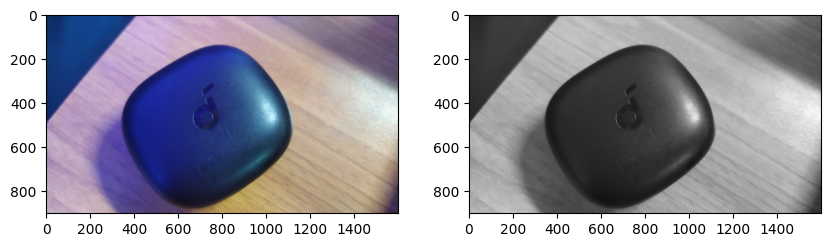

In [ ]:
# 5
# Sesuaikan path dengan lokasi file OBJ1.jpg milik Anda
path_gambar = '/content/drive/MyDrive/PCVK/Images/OBJ1.jpeg'
img_bgr = cv.imread(path_gambar)

if img_bgr is not None:
    # Konversi ruang warna BGR ke RGB (untuk Matplotlib) dan HSV (untuk masking)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

    # Membuat versi grayscale 3-channel agar dimensinya cocok saat digabungkan
    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    img_gray_3ch = cv.cvtColor(img_gray, cv.COLOR_GRAY2RGB)

    # Menentukan rentang nilai HSV untuk warna target (Contoh: Merah)
    # Warna merah pada HSV berada di dua ujung nilai Hue (0-10 dan 160-180)
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)

    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)

    # Menggabungkan kedua mask untuk mencakup seluruh spektrum merah
    mask = mask1 | mask2

    # Mengaplikasikan mask:
    # Jika mask benar (>0), pertahankan warna asli (RGB). Jika salah, gunakan Grayscale.
    hasil = np.where(mask[:, :, None] > 0, img_rgb, img_gray_3ch)

    # Menampilkan hasil dengan sumbu koordinat menggunakan Matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_aspect('equal')

    axes[1].imshow(hasil)
    axes[1].set_aspect('equal')

    plt.show()

else:
    print("Error: File OBJ1.jpg tidak ditemukan.")

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.7

Hasil Gamma Correction (y = 0.7)


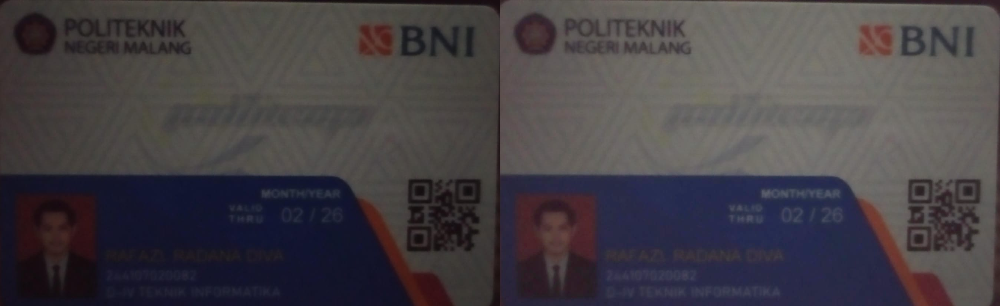

In [ ]:
# 6
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    # Diubah menjadi float agar bisa menerima nilai desimal
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

# Sesuaikan dengan lokasi file Anda
path_gambar = '/content/drive/MyDrive/PCVK/Images/KTM1a.jpeg'
original = cv.imread(path_gambar)

if original is not None:
    # Membangun Lookup Table (LUT) untuk efisiensi pemrosesan
    # Formula standar: piksel_baru = 255 * (piksel_lama / 255) ^ gamma
    # Nilai gamma < 1 akan menerangkan citra, gamma > 1 akan menggelapkan citra
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)

    # Menerapkan transformasi gamma
    gamma_corrected = cv.LUT(original, lookUpTable)

    # Menggabungkan gambar asli dan hasil modifikasi agar tampil berdampingan
    print(f"\nHasil Gamma Correction (y = {gamma})")
    final_frame = cv.hconcat((original, gamma_corrected))
    cv2_imshow(final_frame)
else:
    print("Error: File tidak ditemukan.")

In [ ]:
# 8
import cv2 as cv
import glob
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow

# Sesuaikan dengan path Google Drive Anda
path_asli = '/content/drive/MyDrive/PCVK/Images/galaxy.jpg'
path_noise = '/content/drive/MyDrive/PCVK/Images/noises/*.jpg'

# 1. Membaca citra asli
original = cv.imread(path_asli)

# 2. Membaca 100 citra dengan Gaussian Noise
cv_img = []
for img in glob.glob(path_noise):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

if original is not None and len(cv_img) > 0:
    jumlah_citra_target = [10, 20, 40, 80, 100]
    hasil_psnr = []

    print("Hasil Visual Average Denoising:")
    print("-" * 40)

    for N in jumlah_citra_target:
        # Memastikan tidak melebihi jumlah citra yang berhasil dimuat
        N_actual = min(N, len(cv_img))

        # Inisialisasi matriks kosong dengan tipe float32 untuk mencegah overflow saat penjumlahan
        avg_img = np.zeros_like(original, dtype=np.float32)

        # Menjumlahkan nilai piksel dari N citra
        for i in range(N_actual):
            avg_img += cv_img[i]

        # Membagi dengan N untuk mendapatkan rata-rata, lalu konversi kembali ke uint8 (0-255)
        avg_img = (avg_img / N_actual).astype(np.uint8)

        # Menghitung nilai PSNR menggunakan fungsi bawaan OpenCV
        psnr_value = cv.PSNR(original, avg_img)
        hasil_psnr.append(psnr_value)

        print(f"Jumlah Citra di Average: {N_actual} | PSNR: {psnr_value:.2f} dB")
        # Menampilkan gambar berukuran lebih kecil agar output Colab tidak terlalu panjang
        # cv2_imshow(cv.resize(avg_img, (0,0), fx=0.5, fy=0.5))

    # 3. Menampilkan hasil dalam bentuk Tabel
    df = pd.DataFrame({
        'Jumlah Citra di Average': jumlah_citra_target,
        'Nilai PSNR (dB)': [round(p, 2) for p in hasil_psnr]
    })

    print("\nTabel Hasil Perhitungan PSNR:")
    print("-" * 35)
    print(df.to_string(index=True))

else:
    print("Error: Citra asli atau folder noises tidak ditemukan. Periksa kembali path direktori.")

Hasil Visual Average Denoising:
----------------------------------------
Jumlah Citra di Average: 7 | PSNR: 19.65 dB
Jumlah Citra di Average: 7 | PSNR: 19.65 dB
Jumlah Citra di Average: 7 | PSNR: 19.65 dB
Jumlah Citra di Average: 7 | PSNR: 19.65 dB
Jumlah Citra di Average: 7 | PSNR: 19.65 dB

Tabel Hasil Perhitungan PSNR:
-----------------------------------
   Jumlah Citra di Average  Nilai PSNR (dB)
0                       10            19.65
1                       20            19.65
2                       40            19.65
3                       80            19.65
4                      100            19.65
